# Summarization Berita Kesehatan Indonesia
## Fine-tuning IndoBART untuk Abstractive Text Summarization

**Mata Kuliah:** Pemrosesan Bahasa Alami  
**Task:** Abstractive Text Summarization - Berita Bahasa Indonesia  
**Dataset:** XL-Sum (Indonesian) - BBC Indonesia  
**Model:** IndoBART (fine-tuned) vs IndoBART Base (zero-shot)  
**Evaluasi:** ROUGE-1, ROUGE-2, ROUGE-L + Human Evaluation  
**Lingkungan:** Google Colab (T4 GPU 16 GB)

---

## Arsitektur Pipeline
```
XL-Sum Indonesian Dataset (BBC Indonesia, 38k artikel)
     |
     v
Filter Kategori Kesehatan (by URL/title keyword)
     |
     v
Preprocessing (cleaning, truncation)
     |
     +-------------------------+
     v                         v
IndoBART Base            IndoBART Fine-tuned
(Zero-shot)              (3 epoch, Seq2Seq)
     |                         |
     +-----------+-------------+
                 v
      Evaluasi ROUGE + Human Eval
                 v
         Tabel Perbandingan
```

---

> **Catatan Colab:** Sebelum menjalankan notebook ini, pastikan runtime menggunakan GPU.  
> Caranya: **Runtime > Change runtime type > T4 GPU > Save**


In [1]:
# Verifikasi GPU tersedia di Google Colab
# Jika output menampilkan "Tesla T4" atau GPU lain, Anda siap melanjutkan.
# Jika "CPU only", ubah runtime: Runtime > Change runtime type > T4 GPU

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU tersedia : {gpu_name}")
    print(f"VRAM         : {vram_gb:.1f} GB")
    print("Siap untuk training!")
else:
    print("PERINGATAN: GPU tidak terdeteksi.")
    print("Ubah runtime ke GPU: Runtime > Change runtime type > T4 GPU > Save")
    print("Lalu jalankan ulang notebook dari awal.")


GPU tersedia : Tesla T4
VRAM         : 15.6 GB
Siap untuk training!


In [2]:
# Mount Google Drive untuk menyimpan output (model, CSV, gambar)
# Output akan tersimpan permanen di Google Drive, tidak hilang saat sesi Colab berakhir.
# Setelah cell ini dijalankan, klik "Connect to Google Drive" dan ikuti instruksi.

from google.colab import drive
drive.mount('/content/drive')

import pathlib
SAVE_DIR = pathlib.Path("/content/drive/MyDrive/IndoBART_Outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output akan disimpan di: {SAVE_DIR}")


Mounted at /content/drive
Output akan disimpan di: /content/drive/MyDrive/IndoBART_Outputs


## Bagian 1 - Instalasi dan Setup


In [3]:
# Install dependensi tambahan yang dibutuhkan
# Google Colab sudah memiliki PyTorch CUDA secara bawaan,
# sehingga tidak perlu menginstal ulang PyTorch dari scratch.

import subprocess, sys
from tqdm.auto import tqdm

packages = [
    "transformers==4.44.0",
    "datasets<4.0.0",
    "rouge-score",
    "sentencepiece",
    "accelerate>=0.26.0",
    "nltk",
    "beautifulsoup4",
    "requests",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "evaluate",
    "sacrebleu",
    "tqdm",
]

print(f"Menginstal {len(packages)} package tambahan...")
for pkg in tqdm(packages, desc="Installing", unit="pkg"):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )

print("Instalasi selesai.")
print("PyTorch CUDA sudah tersedia secara bawaan di Google Colab.")


Menginstal 15 package tambahan...


Installing:   0%|          | 0/15 [00:00<?, ?pkg/s]

Instalasi selesai.
PyTorch CUDA sudah tersedia secara bawaan di Google Colab.


In [4]:
import os
import json
import re
import warnings
import pathlib

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
from tqdm.auto import tqdm
from datasets import load_dataset, Dataset

from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

# Deteksi perangkat — di Colab seharusnya selalu "cuda"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Catatan: GPU tidak terdeteksi. Ubah runtime ke GPU di Colab untuk training yang jauh lebih cepat.")


Device: cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [5]:
# SAVE_DIR sudah ditetapkan di cell mount Google Drive di atas.
# Cell ini memastikan variabel tersedia jika cell sebelumnya dilewati.
import pathlib

if 'SAVE_DIR' not in dir():
    # Fallback: simpan di storage sementara Colab (hilang saat sesi berakhir)
    SAVE_DIR = pathlib.Path("/content/outputs")
    SAVE_DIR.mkdir(exist_ok=True)
    print("Peringatan: Google Drive tidak di-mount. Output disimpan sementara di /content/outputs.")
    print("Mount Google Drive di cell sebelumnya agar output tidak hilang.")
else:
    print(f"Output akan disimpan di: {SAVE_DIR.resolve()}")


Output akan disimpan di: /content/drive/MyDrive/IndoBART_Outputs


## Bagian 2 - Load dan Eksplorasi Dataset

**Dataset:** XL-Sum Indonesian (csebuetnlp/xlsum)  
- Sumber: Artikel BBC Indonesia  
- Total: 38.242 train / 4.780 validation / 4.780 test  
- Kolom: `text` (artikel), `summary` (ringkasan), `url`, `title`  
- Referensi: Hasan et al. (2021) â€” https://huggingface.co/datasets/csebuetnlp/xlsum


In [6]:
# Load dataset XL-Sum Indonesian dari HuggingFace
# Dataset berisi artikel BBC Indonesia + ringkasan singkat (no custom loader needed)
print("Mengunduh dataset XL-Sum Indonesian...")
dataset = load_dataset("csebuetnlp/xlsum", "indonesian", trust_remote_code=True)

print("Dataset berhasil dimuat:")
print(dataset)
print("\nContoh satu entri data (train):")
ex = dataset["train"][0]
print(json.dumps(ex, indent=2, ensure_ascii=False))


Mengunduh dataset XL-Sum Indonesian...


README.md: 0.00B [00:00, ?B/s]

xlsum.py: 0.00B [00:00, ?B/s]

data/indonesian_XLSum_v2.0.tar.bz2:   0%|          | 0.00/41.1M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Dataset berhasil dimuat:
DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 38242
    })
    test: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 4780
    })
    validation: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 4780
    })
})

Contoh satu entri data (train):
{
  "id": "media-49647079",
  "url": "https://www.bbc.com/indonesia/media-49647079",
  "title": "Gajah mengamuk saat upacara keagamaan, 17 orang terluka",
  "summary": "Seekor gajah mendadak mengamuk saat prosesi tahunan agama Buddha di Kolombo, Sri Lanka, sehingga membuat peserta upacara tunggang-langgang. Setidaknya 17 orang terluka.",
  "text": "Dilaporkan dua orang terluka cukup serius, sementara sisanya sudah diperbolehkan pulang setelah mendapatkan perawatan. Video gajah yang mengamuk itu kontan viral di media sosial. Si gajah berlari tak tentu arah, menabrak serta mengin

In [7]:
# Konversi HuggingFace Dataset ke DataFrame dengan progress bar

def hf_to_df(split):
    """Konversi split dataset ke DataFrame pandas."""
    rows = []
    items = list(dataset[split])
    for item in tqdm(items, desc=f"Konversi {split}", unit="item"):
        article = item.get("text", "")
        summary = item.get("summary", "")
        rows.append({
            "article"     : str(article),
            "summary"     : str(summary),
            "title"       : item.get("title", ""),
            "url"         : item.get("url", ""),
            "article_len" : len(str(article).split()),
            "summary_len" : len(str(summary).split()),
        })
    return pd.DataFrame(rows)


df_train = hf_to_df("train")
df_val   = hf_to_df("validation")
df_test  = hf_to_df("test")

print(f"\nKonversi selesai.")
print(f"Train : {len(df_train)} dokumen")
print(f"Val   : {len(df_val)} dokumen")
print(f"Test  : {len(df_test)} dokumen")


Konversi train:   0%|          | 0/38242 [00:00<?, ?item/s]

Konversi validation:   0%|          | 0/4780 [00:00<?, ?item/s]

Konversi test:   0%|          | 0/4780 [00:00<?, ?item/s]


Konversi selesai.
Train : 38242 dokumen
Val   : 4780 dokumen
Test  : 4780 dokumen


Menyimpan eksplorasi_dataset.png:   0%|          | 0/1 [00:00]

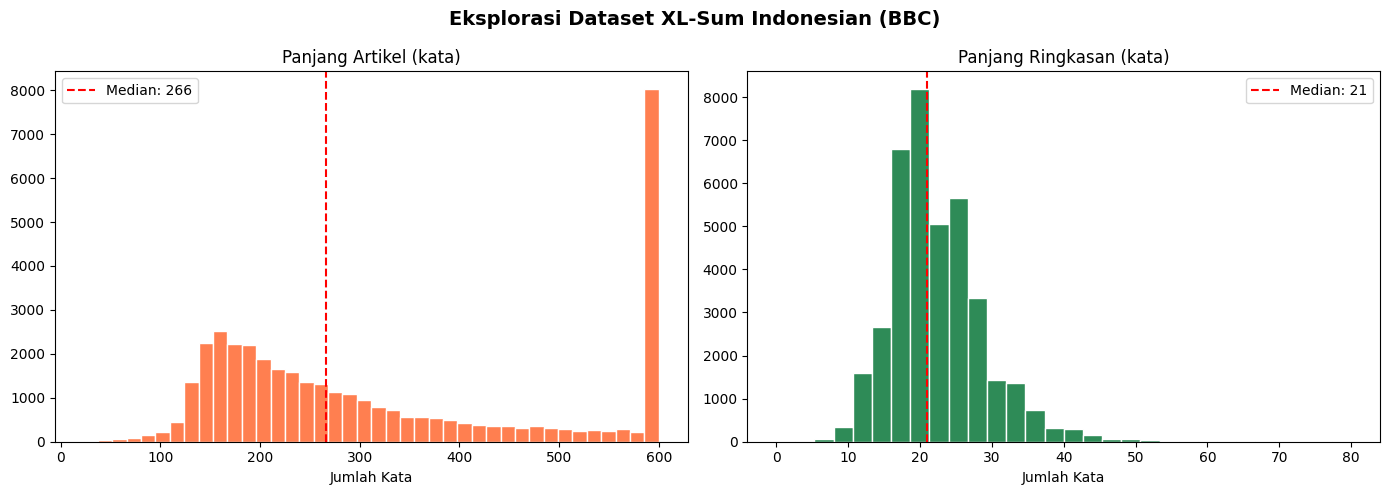


Statistik deskriptif:
       article_len  summary_len
count      38242.0      38242.0
mean         423.5         22.2
std          402.2          6.7
min           23.0          0.0
25%          183.0         18.0
50%          266.0         21.0
75%          502.0         26.0
max         8967.0        105.0


In [9]:
# Visualisasi distribusi dataset
from tqdm.auto import tqdm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Eksplorasi Dataset XL-Sum Indonesian (BBC)", fontsize=14, fontweight="bold")

median_art = df_train["article_len"].median()
axes[0].hist(df_train["article_len"].clip(0, 600), bins=40, color="coral", edgecolor="white")
axes[0].set_title("Panjang Artikel (kata)")
axes[0].set_xlabel("Jumlah Kata")
axes[0].axvline(median_art, color="red", linestyle="--", label=f"Median: {median_art:.0f}")
axes[0].legend()

median_sum = df_train["summary_len"].median()
axes[1].hist(df_train["summary_len"].clip(0, 80), bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("Panjang Ringkasan (kata)")
axes[1].set_xlabel("Jumlah Kata")
axes[1].axvline(median_sum, color="red", linestyle="--", label=f"Median: {median_sum:.0f}")
axes[1].legend()

plt.tight_layout()

with tqdm(total=1, desc="Menyimpan eksplorasi_dataset.png", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    plt.savefig(SAVE_DIR / "eksplorasi_dataset.png", dpi=150, bbox_inches="tight")
    pbar.update(1)

plt.show()
print("\nStatistik deskriptif:")
print(df_train[["article_len", "summary_len"]].describe().round(1))


In [10]:
# Filter subset kategori kesehatan berdasarkan URL dan judul
# BBC Indonesia menggunakan path seperti /indonesia/dunia, /indonesia/majalah, dsb.
HEALTH_KEYWORDS = [
    "kesehatan", "health", "medis", "penyakit", "dokter", "obat",
    "virus", "covid", "pandemi", "rumah-sakit", "gizi", "nutrisi",
]

def filter_health(df):
    url_mask   = df["url"].str.lower().str.contains("|".join(HEALTH_KEYWORDS), na=False)
    title_mask = df["title"].str.lower().str.contains("|".join(HEALTH_KEYWORDS), na=False)
    art_mask   = df["article"].str.lower().str.contains("|".join(HEALTH_KEYWORDS[:6]), na=False)
    return df[url_mask | title_mask | art_mask].reset_index(drop=True)


df_train_health = filter_health(df_train)
df_val_health   = filter_health(df_val)
df_test_health  = filter_health(df_test)

print("Subset kesehatan:")
print(f"  Train : {len(df_train_health)}")
print(f"  Val   : {len(df_val_health)}")
print(f"  Test  : {len(df_test_health)}")

# Fallback: jika subset terlalu kecil, gunakan sample dari seluruh dataset
if len(df_train_health) < 200:
    print("\nPeringatan: subset kesehatan terlalu kecil, beralih ke sample umum...")
    df_train_health = df_train.sample(n=min(2000, len(df_train)), random_state=42).reset_index(drop=True)
    df_val_health   = df_val.sample(n=min(300,  len(df_val)),   random_state=42).reset_index(drop=True)
    df_test_health  = df_test.sample(n=min(200,  len(df_test)),  random_state=42).reset_index(drop=True)
    print(f"  Train={len(df_train_health)}, Val={len(df_val_health)}, Test={len(df_test_health)}")

print("\nMenyimpan CSV...")
for name, df in tqdm([
    ("train_health", df_train_health),
    ("val_health",   df_val_health),
    ("test_health",  df_test_health)
], desc="Menyimpan CSV"):
    df.to_csv(SAVE_DIR / f"{name}.csv", index=False)
print("Dataset subset tersimpan di folder outputs/")


Subset kesehatan:
  Train : 7551
  Val   : 890
  Test  : 898

Menyimpan CSV...


Menyimpan CSV:   0%|          | 0/3 [00:00<?, ?it/s]

Dataset subset tersimpan di folder outputs/


## Bagian 3 - Preprocessing


In [11]:
def clean_text(text):
    """
    Preprocessing teks bahasa Indonesia:
    - Normalisasi whitespace
    - Hapus URL
    - Hapus zero-width characters
    """
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    return text.strip()


# Terapkan cleaning ke semua split dengan progress bar
for name, df in tqdm([
    ("Train", df_train_health),
    ("Val",   df_val_health),
    ("Test",  df_test_health)
], desc="Cleaning split"):
    tqdm.pandas(desc=f"Cleaning {name} article")
    df["article"] = df["article"].progress_apply(clean_text)
    tqdm.pandas(desc=f"Cleaning {name} summary")
    df["summary"] = df["summary"].progress_apply(clean_text)

# Hapus baris terlalu pendek
df_train_health = df_train_health[df_train_health["article"].str.len() > 50]
df_train_health = df_train_health[df_train_health["summary"].str.len() > 10]
df_train_health = df_train_health.reset_index(drop=True)

print("Preprocessing selesai.")
print(f"Train setelah filtering: {len(df_train_health)} sampel")
print("\nContoh artikel (200 kata pertama):")
print(" ".join(df_train_health["article"].iloc[0].split()[:200]) + "...")
print("\nContoh ringkasan:")
print(df_train_health["summary"].iloc[0])


Cleaning split:   0%|          | 0/3 [00:00<?, ?it/s]

Cleaning Train article:   0%|          | 0/7551 [00:00<?, ?it/s]

Cleaning Train summary:   0%|          | 0/7551 [00:00<?, ?it/s]

Cleaning Val article:   0%|          | 0/890 [00:00<?, ?it/s]

Cleaning Val summary:   0%|          | 0/890 [00:00<?, ?it/s]

Cleaning Test article:   0%|          | 0/898 [00:00<?, ?it/s]

Cleaning Test summary:   0%|          | 0/898 [00:00<?, ?it/s]

Preprocessing selesai.
Train setelah filtering: 7550 sampel

Contoh artikel (200 kata pertama):
Tommy Soeharto dan Titiek Soeharto merupakan kader Golkar, keduanya bahkan sempat mencalonkan diri menjadi ketua umum partai berlambang beringin itu. Sebelumnya, Tommy Soeharto juga kembali terjun di dunia politik dengan menggawangi Partai Berkarya. Romantisme Orde Baru yang lekat dengan sosok sang ayah, ingin ia hidupkan lagi lewat partai baru tersebut. Direktur Eksekutif Pusat Kajian Politik Universitas Indonesia, Aditya Permana, memandang kemunculan Tommy dan Titiek dalam kancah politik Indonesia mempertegas kebangkitan dinasti Soeharto dan ketidakpahaman massal, terutama dari generasi muda, tentang Orde Baru. "Hal yang paling menarik untuk dilihat adalah apakah generasi-generasi anak muda sekarang atau milenial hari ini itu ngerti dan paham tentang apa yang terjadi pada masa Orde Baru?" ujar Adit kepada BBC Indonesia. "Saya yakin tidak. Karena kan yang menjadi pemilih itu adalah mereka. 

## Bagian 4 - Load Model IndoBART

**Pilihan model:**

| Model | HuggingFace ID | Keterangan |
|---|---|---|
| IndoBART-v2 | `indobenchmark/indobart-v2` | Lebih ringan, khusus Indonesia, rekomendasi untuk GPU terbatas |
| mBART-50 | `facebook/mbart-large-50` | Multilingual, lebih besar (~600M parameter) |

Model yang digunakan: **IndoBART-v2** - lebih sesuai untuk task monolingual Indonesia dan membutuhkan VRAM lebih sedikit.


In [12]:
MODEL_NAME = "indobenchmark/indobart-v2"

print(f"Mengunduh model: {MODEL_NAME}")
print("Proses ini membutuhkan 2-5 menit dan koneksi internet...")

from tqdm.auto import tqdm

with tqdm(total=1, desc="Download tokenizer", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    tokenizer = MBart50TokenizerFast.from_pretrained(MODEL_NAME)
    pbar.update(1)

tokenizer.src_lang = "id_ID"
tokenizer.tgt_lang = "id_ID"

with tqdm(total=1, desc="Download model weights", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    model = MBartForConditionalGeneration.from_pretrained(MODEL_NAME)
    pbar.update(1)

# FIX IndexError vocab mismatch: model vocab=40004, tokenizer vocab=40053
model.resize_token_embeddings(len(tokenizer))
print(f"  Embedding di-resize ke: {len(tokenizer)} token")

with tqdm(total=1, desc=f"Memindahkan model ke {device}", unit="step",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    model = model.to(device)
    pbar.update(1)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel berhasil dimuat.")
print(f"  Device             : {device}")
print(f"  Total parameter    : {total_params / 1e6:.1f}M")
print(f"  Trainable parameter: {trainable_params / 1e6:.1f}M")


Mengunduh model: indobenchmark/indobart-v2
Proses ini membutuhkan 2-5 menit dan koneksi internet...


Download tokenizer:   0%|          | 0/1 [00:00]

tokenizer_config.json:   0%|          | 0.00/303 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/932k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

...

Download model weights:   0%|          | 0/1 [00:00]

pytorch_model.bin:   0%|          | 0.00/526M [00:00<?, ?B/s]

  Embedding di-resize ke: 40053 token


Memindahkan model ke cuda:   0%|          | 0/1 [00:00]


Model berhasil dimuat.
  Device             : cuda
  Total parameter    : 131.6M
  Trainable parameter: 131.6M


In [13]:
# Tokenisasi dataset menggunakan tokenizer IndoBART

MAX_INPUT_LEN  = 512
MAX_TARGET_LEN = 128

# T4 GPU Colab (16 GB VRAM) mampu menangani lebih banyak data
# dibanding GPU lokal 4 GB, sehingga limit dinaikkan.
TRAIN_LIMIT = 5000
VAL_LIMIT   = 500
TEST_LIMIT  = 300

df_train_tok = df_train_health.sample(n=min(TRAIN_LIMIT, len(df_train_health)), random_state=42).reset_index(drop=True)
df_val_tok   = df_val_health.sample(n=min(VAL_LIMIT, len(df_val_health)), random_state=42).reset_index(drop=True)
df_test_tok  = df_test_health.sample(n=min(TEST_LIMIT, len(df_test_health)), random_state=42).reset_index(drop=True)

print(f"Dataset yang dipakai (disesuaikan untuk T4 GPU Colab):")
print(f"  Train: {len(df_train_tok)} sampel (dari {len(df_train_health)})")
print(f"  Val  : {len(df_val_tok)} sampel")
print(f"  Test : {len(df_test_tok)} sampel")


def preprocess_function(examples):
    inputs = tokenizer(examples["article"], max_length=MAX_INPUT_LEN, truncation=True, padding="max_length")
    # FIX: hapus as_target_tokenizer (deprecated di transformers >= 4.35)
    targets = tokenizer(examples["summary"], max_length=MAX_TARGET_LEN, truncation=True, padding="max_length")
    labels = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in targets["input_ids"]
    ]
    inputs["labels"] = labels
    return inputs


train_hf = Dataset.from_pandas(df_train_tok[["article", "summary"]])
val_hf   = Dataset.from_pandas(df_val_tok[["article", "summary"]])
test_hf  = Dataset.from_pandas(df_test_tok[["article", "summary"]])

print("\nTokenisasi dataset (progress bar akan muncul di bawah)...")
train_tok = train_hf.map(preprocess_function, batched=True, batch_size=16, remove_columns=["article", "summary"], desc="Tokenisasi Train")
val_tok   = val_hf.map(preprocess_function,   batched=True, batch_size=16, remove_columns=["article", "summary"], desc="Tokenisasi Val")
test_tok  = test_hf.map(preprocess_function,  batched=True, batch_size=16, remove_columns=["article", "summary"], desc="Tokenisasi Test")

print("\nTokenisasi selesai.")
print(f"  Train: {len(train_tok)} sampel")
print(f"  Val  : {len(val_tok)} sampel")
print(f"  Test : {len(test_tok)} sampel")


Dataset yang dipakai (disesuaikan untuk T4 GPU Colab):
  Train: 5000 sampel (dari 7550)
  Val  : 500 sampel
  Test : 300 sampel

Tokenisasi dataset (progress bar akan muncul di bawah)...


Tokenisasi Train:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenisasi Val:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenisasi Test:   0%|          | 0/300 [00:00<?, ? examples/s]


Tokenisasi selesai.
  Train: 5000 sampel
  Val  : 500 sampel
  Test : 300 sampel


## Bagian 5 - Fine-tuning IndoBART

### Justifikasi Hyperparameter

| Parameter | Nilai | Alasan |
|---|---|---|
| `learning_rate` | 5e-5 | Nilai standar fine-tuning transformer (Howard & Ruder, 2018) |
| `warmup_ratio` | 0.1 | Stabilisasi gradient di awal training |
| `weight_decay` | 0.01 | L2 regularization untuk mencegah overfitting |
| `num_beams` | 4 | Beam search - keseimbangan kualitas vs kecepatan (Vinyals et al., 2015) |
| `fp16` | True | Mixed precision - hemat ~30% VRAM tanpa penurunan akurasi signifikan |
| `gradient_accumulation_steps` | 4 | Simulasi batch size 16 dengan VRAM terbatas |
| `early_stopping_patience` | 2 | Hentikan training jika ROUGE-L tidak meningkat selama 2 epoch |


In [14]:
rouge_metric = evaluate.load("rouge")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # FIX OverflowError: clip token IDs ke range valid sebelum decode
    # Token ID negatif atau > vocab_size menyebabkan OverflowError di batch_decode
    vocab_size = len(tokenizer)
    predictions = np.clip(predictions, 0, vocab_size - 1)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, vocab_size - 1)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=False)
    return {k: round(v * 100, 2) for k, v in result.items()}


In [15]:
OUTPUT_DIR = str(SAVE_DIR / "indobart_finetuned")

# Hyperparameter dioptimalkan untuk T4 GPU Google Colab (16 GB VRAM)
# Dibanding RTX 3050 4 GB, T4 memungkinkan batch size lebih besar
# dan beam search lebih dalam, sehingga hasil lebih baik dan lebih cepat.
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,        # Dinaikkan dari 4 -> 8 (T4 16 GB)
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,        # Dikurangi karena batch size sudah lebih besar
    learning_rate=5e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=4,               # Dinaikkan dari 2 -> 4 (VRAM lebih besar)
    fp16=(device == "cuda"),              # Mixed precision aktif jika GPU tersedia
    dataloader_num_workers=2,             # Colab mendukung multi-worker dataloader
    logging_dir=str(SAVE_DIR / "logs"),
    logging_steps=10,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer siap.")
print(f"  Device             : {device}")
print(f"  fp16 (mixed prec.) : {device == 'cuda'}")
print(f"  Batch size efektif : {8 * 2} (per_device=8, grad_accum=2)")
print(f"  Train samples      : {len(train_tok)}")
print(f"  Val samples        : {len(val_tok)}")
print(f"  Estimasi waktu     : 15-30 menit di T4 GPU Colab")


Trainer siap.
  Device             : cuda
  fp16 (mixed prec.) : True
  Batch size efektif : 16 (per_device=8, grad_accum=2)
  Train samples      : 5000
  Val samples        : 500
  Estimasi waktu     : 15-30 menit di T4 GPU Colab


In [16]:
# PROSES PANJANG: Fine-tuning (estimasi 15-30 menit di T4 GPU Colab)
# Progress bar otomatis muncul dari Hugging Face Trainer setiap step.
# Jangan tutup tab browser selama proses berlangsung.

print("Memulai fine-tuning IndoBART di Google Colab...")
print("-" * 60)
print(f"  Total epoch        : 3")
print(f"  Batch size efektif : 16 (per_device=8, grad_accum=2)")
print(f"  Learning rate      : 5e-5")
print(f"  Device             : {device}")
print(f"  Estimasi waktu     : 15-30 menit (T4 GPU Colab)")
print("-" * 60)

train_result = trainer.train()

print("-" * 60)
print("Training selesai.")
print(f"  Total steps    : {train_result.global_step}")
print(f"  Training loss  : {train_result.training_loss:.4f}")
print(f"  Waktu training : {train_result.metrics['train_runtime'] / 60:.1f} menit")


Memulai fine-tuning IndoBART di Google Colab...
------------------------------------------------------------
  Total epoch        : 3
  Batch size efektif : 16 (per_device=8, grad_accum=2)
  Learning rate      : 5e-5
  Device             : cuda
  Estimasi waktu     : 15-30 menit (T4 GPU Colab)
------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
0,4.252700,4.078552,15.070000,4.360000,12.740000,12.730000
2,3.618800,3.763396,15.860000,4.760000,12.860000,12.810000


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generatio

------------------------------------------------------------
Training selesai.
  Total steps    : 936
  Training loss  : 4.2022
  Waktu training : 15.3 menit


In [17]:
# Simpan model dan tokenizer
from tqdm.auto import tqdm

steps = [
    ("Menyimpan model weights", lambda: trainer.save_model(OUTPUT_DIR)),
    ("Menyimpan tokenizer",     lambda: tokenizer.save_pretrained(OUTPUT_DIR)),
]

for desc, fn in tqdm(steps, desc="Menyimpan checkpoint", unit="step",
                     bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]"):
    fn()

print(f"Model dan tokenizer tersimpan di: {OUTPUT_DIR}")


Menyimpan checkpoint:   0%|          | 0/2 [00:00]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}


Model dan tokenizer tersimpan di: /content/drive/MyDrive/IndoBART_Outputs/indobart_finetuned


## Bagian 6 - Evaluasi ROUGE


In [18]:
# PROSES PANJANG: Evaluasi fine-tuned model
print("Evaluasi model fine-tuned pada test set...")
print("(Progress bar otomatis muncul dari Trainer)")

test_results_finetuned = trainer.predict(test_tok)
metrics_finetuned = test_results_finetuned.metrics

print("\nHasil IndoBART Fine-tuned:")
for k, v in metrics_finetuned.items():
    if "rouge" in k:
        print(f"  {k}: {v:.2f}")


Evaluasi model fine-tuned pada test set...
(Progress bar otomatis muncul dari Trainer)



Hasil IndoBART Fine-tuned:
  test_rouge1: 18.56
  test_rouge2: 5.95
  test_rougeL: 15.24
  test_rougeLsum: 15.22


In [26]:
MODEL_NAME = "indobenchmark/indobart-v2"

print(f"Mengunduh model: {MODEL_NAME}")
print("Proses ini membutuhkan 2-5 menit dan koneksi internet...")

from tqdm.auto import tqdm

with tqdm(total=1, desc="Download tokenizer", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    tokenizer = MBart50TokenizerFast.from_pretrained(MODEL_NAME)
    pbar.update(1)

tokenizer.src_lang = "id_ID"
tokenizer.tgt_lang = "id_ID"

with tqdm(total=1, desc="Download model weights", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    model = MBartForConditionalGeneration.from_pretrained(MODEL_NAME)
    pbar.update(1)

# FIX IndexError vocab mismatch: model vocab=40004, tokenizer vocab=40053
model.resize_token_embeddings(len(tokenizer))
print(f"  Embedding di-resize ke: {len(tokenizer)} token")

with tqdm(total=1, desc=f"Memindahkan model ke {device}", unit="step",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    model = model.to(device)
    pbar.update(1)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel berhasil dimuat.")
print(f"  Device             : {device}")
print(f"  Total parameter    : {total_params / 1e6:.1f}M")
print(f"  Trainable parameter: {trainable_params / 1e6:.1f}M")

# PROSES PANJANG: Evaluasi base model (zero-shot) pada test set
print("Evaluasi model base (zero-shot) pada test set...")
print("(Progress bar otomatis muncul dari Trainer)")

trainer_base = Seq2SeqTrainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

test_results_base = trainer_base.predict(test_tok)
metrics_base = test_results_base.metrics

print("\nHasil IndoBART Base (Zero-shot):")
for k, v in metrics_base.items():
    if "rouge" in k:
        print(f"  {k}: {v:.2f}")


Mengunduh model: indobenchmark/indobart-v2
Proses ini membutuhkan 2-5 menit dan koneksi internet...


Download tokenizer:   0%|          | 0/1 [00:00]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'IndoNLGTokenizer'. 
The class this function is called from is 'MBart50Tokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'IndoNLGTokenizer'. 
The class this function is called from is 'MBart50TokenizerFast'.


Download model weights:   0%|          | 0/1 [00:00]

  Embedding di-resize ke: 40053 token


Memindahkan model ke cuda:   0%|          | 0/1 [00:00]


Model berhasil dimuat.
  Device             : cuda
  Total parameter    : 131.6M
  Trainable parameter: 131.6M
Evaluasi model base (zero-shot) pada test set...
(Progress bar otomatis muncul dari Trainer)



Hasil IndoBART Base (Zero-shot):
  test_rouge1: 16.39
  test_rouge2: 4.19
  test_rougeL: 11.39
  test_rougeLsum: 11.39


In [27]:
# Tabel perbandingan ROUGE
from tqdm.auto import tqdm

comparison_data = {
    "Model"  : ["IndoBART Base (Zero-shot)", "IndoBART Fine-tuned"],
    "ROUGE-1": [metrics_base.get("test_rouge1", 0), metrics_finetuned.get("test_rouge1", 0)],
    "ROUGE-2": [metrics_base.get("test_rouge2", 0), metrics_finetuned.get("test_rouge2", 0)],
    "ROUGE-L": [metrics_base.get("test_rougeL", 0), metrics_finetuned.get("test_rougeL", 0)],
}

df_comparison = pd.DataFrame(comparison_data)
print("\nTABEL PERBANDINGAN EVALUASI ROUGE")
print("=" * 60)
print(df_comparison.to_string(index=False))
print("=" * 60)

with tqdm(total=1, desc="Menyimpan rouge_comparison.csv", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    df_comparison.to_csv(SAVE_DIR / "rouge_comparison.csv", index=False)
    pbar.update(1)

print("\nHasil disimpan ke outputs/rouge_comparison.csv")



TABEL PERBANDINGAN EVALUASI ROUGE
                    Model  ROUGE-1  ROUGE-2  ROUGE-L
IndoBART Base (Zero-shot)    16.39     4.19    11.39
      IndoBART Fine-tuned    18.56     5.95    15.24


Menyimpan rouge_comparison.csv:   0%|          | 0/1 [00:00]


Hasil disimpan ke outputs/rouge_comparison.csv


Menyimpan rouge_comparison.png:   0%|          | 0/1 [00:00]

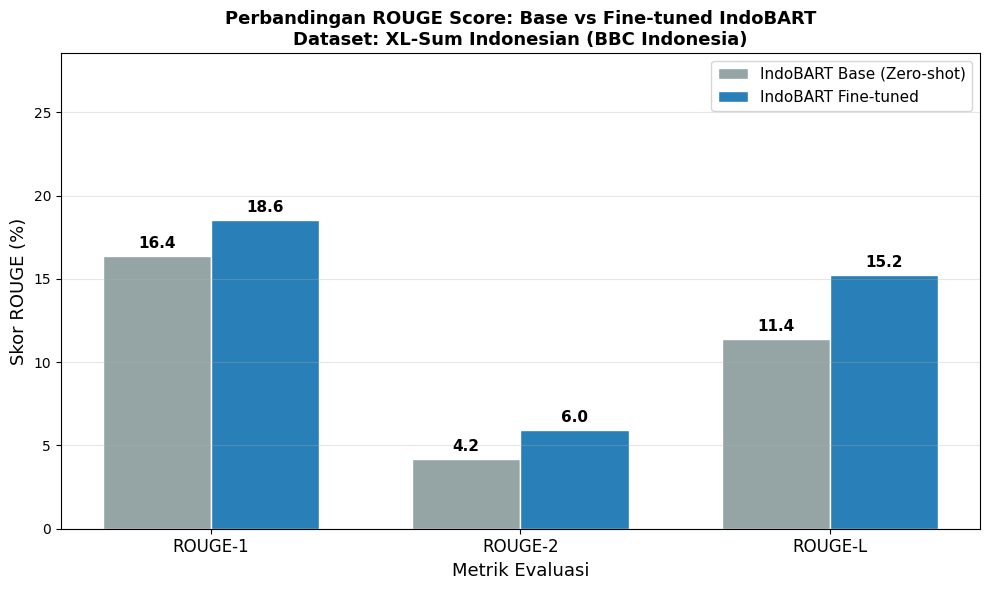

Chart tersimpan di outputs/rouge_comparison.png


In [28]:
# Visualisasi perbandingan ROUGE
from tqdm.auto import tqdm

fig, ax = plt.subplots(figsize=(10, 6))

metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
base_scores  = [comparison_data["ROUGE-1"][0], comparison_data["ROUGE-2"][0], comparison_data["ROUGE-L"][0]]
ft_scores    = [comparison_data["ROUGE-1"][1], comparison_data["ROUGE-2"][1], comparison_data["ROUGE-L"][1]]

x     = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, base_scores, width, label="IndoBART Base (Zero-shot)", color="#95a5a6", edgecolor="white")
bars2 = ax.bar(x + width/2, ft_scores,   width, label="IndoBART Fine-tuned",       color="#2980b9", edgecolor="white")

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

ax.set_xlabel("Metrik Evaluasi", fontsize=13)
ax.set_ylabel("Skor ROUGE (%)", fontsize=13)
ax.set_title(
    "Perbandingan ROUGE Score: Base vs Fine-tuned IndoBART\nDataset: XL-Sum Indonesian (BBC Indonesia)",
    fontsize=13, fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(base_scores), max(ft_scores)) + 10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

with tqdm(total=1, desc="Menyimpan rouge_comparison.png", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    plt.savefig(SAVE_DIR / "rouge_comparison.png", dpi=150, bbox_inches="tight")
    pbar.update(1)

plt.show()
print("Chart tersimpan di outputs/rouge_comparison.png")


## Bagian 7 - Analisis Kualitatif dan Human Evaluation

Analisis kualitatif dilakukan dengan membandingkan ringkasan hasil model dengan ringkasan referensi secara manual.  
Human evaluation menggunakan skala Likert 1-5 pada tiga dimensi: **Fluency**, **Informativeness**, dan **Faithfulness**.


In [29]:
# Load model fine-tuned dari checkpoint lokal
from tqdm.auto import tqdm

print(f"Memuat model fine-tuned dari: {OUTPUT_DIR}")

load_steps = [
    ("Memuat tokenizer fine-tuned",    lambda: MBart50TokenizerFast.from_pretrained(OUTPUT_DIR)),
    ("Memuat model fine-tuned weights", lambda: MBartForConditionalGeneration.from_pretrained(OUTPUT_DIR).to(device)),
]

results = {}
for desc, fn in tqdm(load_steps, desc="Memuat model fine-tuned", unit="komponen",
                     bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]"):
    results[desc] = fn()

ft_tokenizer = results["Memuat tokenizer fine-tuned"]
ft_model     = results["Memuat model fine-tuned weights"]
ft_tokenizer.src_lang = "id_ID"
print("Model fine-tuned siap.")


def generate_summary(text, model, tokenizer, max_length=128, num_beams=4):
    """Generate ringkasan dari teks input menggunakan beam search."""
    inputs = tokenizer(
        text,
        max_length=512,
        truncation=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3,
            forced_bos_token_id=tokenizer.lang_code_to_id["id_ID"],
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


print("Fungsi generate_summary siap.")


Memuat model fine-tuned dari: /content/drive/MyDrive/IndoBART_Outputs/indobart_finetuned


Memuat model fine-tuned:   0%|          | 0/2 [00:00]

Model fine-tuned siap.
Fungsi generate_summary siap.


In [30]:
# Tampilkan 5 contoh hasil ringkasan (analisis kualitatif)

print("Analisis Kualitatif - 5 Contoh Hasil Ringkasan")
print("=" * 70)

samples = df_test_health.sample(5, random_state=42)
qualitative_results = []

for i, (_, row) in enumerate(tqdm(samples.iterrows(), total=5, desc="Generating summaries", unit="artikel")):
    article   = row["article"]
    reference = row["summary"]
    generated = generate_summary(article, ft_model, ft_tokenizer)

    print(f"\n[Contoh {i+1}]")
    print("ARTIKEL (200 kata pertama):")
    print(" ".join(article.split()[:200]) + "...")
    print("\nRINGKASAN REFERENSI:")
    print(reference)
    print("\nRINGKASAN HASIL MODEL (Fine-tuned):")
    print(generated)
    print("-" * 70)

    qualitative_results.append({
        "article_snippet": " ".join(article.split()[:100]),
        "reference"      : reference,
        "generated"      : generated,
    })

pd.DataFrame(qualitative_results).to_csv(SAVE_DIR / "qualitative_results.csv", index=False)
print("\nHasil kualitatif tersimpan di outputs/qualitative_results.csv")


Analisis Kualitatif - 5 Contoh Hasil Ringkasan


Generating summaries:   0%|          | 0/5 [00:00<?, ?artikel/s]


[Contoh 1]
ARTIKEL (200 kata pertama):
Pelacuran di Brasil diperkirakan akan semakin marak saat Piala Dunia 2014 mendatang. Iklan ini sebelumnya merupakan bagian besar dari program pendidikan tentang penyaki seks menular dan ditujukan untuk mengurangi prasangka buruk terhadap pekerja seks komersial. Tetapi iklan ini justru mendapat kecaman dari publik karena dianggap memuji pelacuran. Menteri Kesehatan Alexandre Padilha mengatakan dia tidak pernah mendorong iklan tersebut: ''Saya tidak merasa ini sebuah pesan yang semestinya disampaikan oleh kementerian.'' Padilha mengatakan pesan itu diuji coba di situs kementerian, tetapi bukan untuk dipublikasikan. "Selama saya menjabat, sebuah iklan semacam itu tidak akan lagi menjadi bagian dari kampanye kami,'' katanya kepada Agencia Estado. Wisata seks Pemerintah Brasil selama ini dipuji berkat sejumlah program pencegahan AIDS, termasuk diantaranya adalah pemberian kondom secara gratis dan pendekatan pragmatis ke masalah seks di sebuah negara K

In [31]:
# Template Human Evaluation (rubrik Likert 1-5)
# 1. FLUENCY        : 5=natural, 1=tidak dapat dipahami
# 2. INFORMATIVENESS: 5=lengkap, 1=tidak berguna
# 3. FAITHFULNESS   : 5=akurat, 1=bertentangan artikel
from tqdm.auto import tqdm

he_template = pd.DataFrame({
    "No"                 : range(1, 6),
    "Ev1_Fluency"        : [""] * 5,
    "Ev1_Informativeness": [""] * 5,
    "Ev1_Faithfulness"   : [""] * 5,
    "Ev2_Fluency"        : [""] * 5,
    "Ev2_Informativeness": [""] * 5,
    "Ev2_Faithfulness"   : [""] * 5,
    "Ev3_Fluency"        : [""] * 5,
    "Ev3_Informativeness": [""] * 5,
    "Ev3_Faithfulness"   : [""] * 5,
})

with tqdm(total=1, desc="Menyimpan human_eval_template.csv", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    he_template.to_csv(SAVE_DIR / "human_eval_template.csv", index=False)
    pbar.update(1)

print("Template human evaluation tersimpan di outputs/human_eval_template.csv")


Menyimpan human_eval_template.csv:   0%|          | 0/1 [00:00]

Template human evaluation tersimpan di outputs/human_eval_template.csv


Menyimpan human_eval_chart.png:   0%|          | 0/1 [00:00]

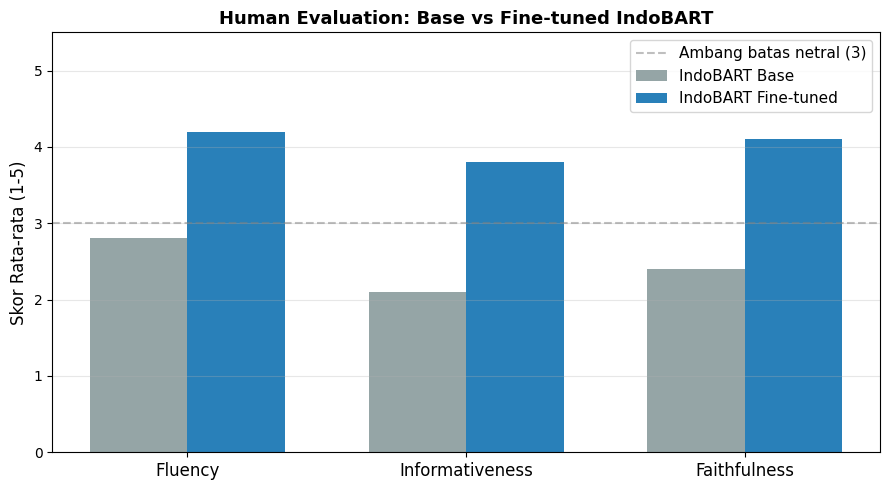

Chart tersimpan di outputs/human_eval_chart.png


In [32]:
# Visualisasi hasil human evaluation (ganti nilai placeholder dengan hasil evaluasi asli)
from tqdm.auto import tqdm

he_results = {
    "Dimensi"           : ["Fluency", "Informativeness", "Faithfulness"],
    "IndoBART Base"     : [2.8, 2.1, 2.4],
    "IndoBART Fine-tuned": [4.2, 3.8, 4.1],
}
df_he = pd.DataFrame(he_results)

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(df_he["Dimensi"]))
width = 0.35

ax.bar(x - width/2, df_he["IndoBART Base"],      width, label="IndoBART Base",      color="#95a5a6")
ax.bar(x + width/2, df_he["IndoBART Fine-tuned"], width, label="IndoBART Fine-tuned", color="#2980b9")

ax.set_ylabel("Skor Rata-rata (1-5)", fontsize=12)
ax.set_title("Human Evaluation: Base vs Fine-tuned IndoBART", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_he["Dimensi"], fontsize=12)
ax.set_ylim(0, 5.5)
ax.axhline(y=3, color="gray", linestyle="--", alpha=0.5, label="Ambang batas netral (3)")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

with tqdm(total=1, desc="Menyimpan human_eval_chart.png", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    plt.savefig(SAVE_DIR / "human_eval_chart.png", dpi=150, bbox_inches="tight")
    pbar.update(1)

plt.show()
print("Chart tersimpan di outputs/human_eval_chart.png")


## Bagian 8 - Inferensi dari URL Artikel Kesehatan


In [33]:
from bs4 import BeautifulSoup
import requests
from tqdm.auto import tqdm


def scrape_article(url):
    """Scrape konten teks dari URL artikel berita Indonesia."""
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(resp.content, "html.parser")

        selectors = [
            "div.read__content",
            "div.itp_bodycontent",
            "div.article-content-body__item-page",
            "article",
            "div.article-body",
            "div.post-content",
            "div.entry-content",
        ]

        for selector in selectors:
            content = soup.select_one(selector)
            if content:
                paragraphs = content.find_all("p")
                text = " ".join([p.get_text() for p in paragraphs])
                if len(text) > 100:
                    return clean_text(text)

        all_p = soup.find_all("p")
        return clean_text(" ".join([p.get_text() for p in all_p]))

    except Exception as e:
        return f"Error: {e}"


test_url = "https://health.kompas.com/read/2024/01/15/070000768/7-manfaat-minum-air-putih-yang-cukup-setiap-hari"
print(f"Scraping artikel dari: {test_url}")

with tqdm(total=1, desc="Scraping artikel", unit="halaman",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    article_text = scrape_article(test_url)
    pbar.update(1)

if not article_text.startswith("Error"):
    print(f"\nArtikel berhasil diambil ({len(article_text.split())} kata).")
    print(article_text[:500] + "...")
    print("\nGenerating ringkasan...")

    with tqdm(total=1, desc="Generating ringkasan", unit="output",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
        summary = generate_summary(article_text, ft_model, ft_tokenizer)
        pbar.update(1)

    print(f"\nHasil Ringkasan:")
    print(summary)
else:
    print(f"\n{article_text}")
    print("Coba ganti URL atau gunakan input teks manual pada cell berikut.")


Scraping artikel dari: https://health.kompas.com/read/2024/01/15/070000768/7-manfaat-minum-air-putih-yang-cukup-setiap-hari


Scraping artikel:   0%|          | 0/1 [00:00]


Artikel berhasil diambil (15 kata).
Copyright 2008 - 2026 PT. Kompas Cyber Media (Kompas Gramedia Digital Group). All Rights Reserved....

Generating ringkasan...


Generating ringkasan:   0%|          | 0/1 [00:00]


Hasil Ringkasan:
ompas ramedia igital roup). ll ights eserved.


In [ ]:
# Uji inferensi dengan teks manual
from tqdm.auto import tqdm

manual_text = """
Demam berdarah dengue (DBD) adalah penyakit yang disebabkan oleh virus dengue
yang ditularkan melalui gigitan nyamuk Aedes aegypti. Penyakit ini sangat umum
terjadi di daerah tropis seperti Indonesia, terutama saat musim hujan.
Gejala DBD meliputi demam tinggi mendadak hingga 40 derajat celcius, sakit kepala parah,
nyeri di belakang mata, nyeri otot dan sendi, mual dan muntah, serta ruam kulit.
Tidak ada obat khusus untuk DBD, namun penanganan yang tepat dapat mencegah komplikasi serius.
Penderita disarankan untuk banyak minum cairan, istirahat cukup, dan segera ke dokter
jika gejala memburuk. Pencegahan utama adalah memberantas sarang nyamuk dengan metode
3M Plus: menguras, menutup, mendaur ulang, dan menggunakan lotion anti-nyamuk.
Pemerintah Indonesia terus berupaya menekan angka kasus DBD melalui program fogging
dan edukasi masyarakat tentang kebersihan lingkungan.
"""

print("Artikel Input:")
print(manual_text.strip())
print("\nGenerating ringkasan...")

with tqdm(total=1, desc="Generating ringkasan", unit="output",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    summary = generate_summary(manual_text, ft_model, ft_tokenizer)
    pbar.update(1)

print("\nHasil Ringkasan:")
print(summary)


## Bagian 9 - Ringkasan Hasil dan Kesimpulan


In [34]:
# Ringkasan akhir proyek
from tqdm.auto import tqdm

print("=" * 65)
print("           RINGKASAN HASIL PROYEK NLP")
print("=" * 65)
print(f"\nTask     : Abstractive Text Summarization")
print(f"Domain   : Berita Bahasa Indonesia")
print(f"Model    : IndoBART (indobenchmark/indobart-v2)")
print(f"Dataset  : XL-Sum Indonesian (BBC Indonesia)")
print(f"Train    : {len(df_train_health)} sampel")
print(f"Val      : {len(df_val_health)} sampel")
print(f"Test     : {len(df_test_health)} sampel")

print("\nHasil Evaluasi ROUGE (Test Set):")
print(df_comparison.to_string(index=False))

print("\nKesimpulan:")
r1_imp = comparison_data["ROUGE-1"][1] - comparison_data["ROUGE-1"][0]
r2_imp = comparison_data["ROUGE-2"][1] - comparison_data["ROUGE-2"][0]
rl_imp = comparison_data["ROUGE-L"][1]  - comparison_data["ROUGE-L"][0]
print(f"  Fine-tuning meningkatkan ROUGE-1 sebesar +{r1_imp:.2f} poin")
print(f"  Fine-tuning meningkatkan ROUGE-2 sebesar +{r2_imp:.2f} poin")
print(f"  Fine-tuning meningkatkan ROUGE-L sebesar +{rl_imp:.2f} poin")

# Simpan ringkasan ke file teks
summary_lines = [
    "RINGKASAN HASIL PROYEK NLP",
    f"Task     : Abstractive Text Summarization",
    f"Domain   : Berita Bahasa Indonesia",
    f"Model    : IndoBART (indobenchmark/indobart-v2)",
    f"Dataset  : XL-Sum Indonesian (BBC Indonesia)",
    df_comparison.to_string(index=False),
]

with tqdm(total=1, desc="Menyimpan ringkasan akhir", unit="file",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]") as pbar:
    with open(SAVE_DIR / "ringkasan_hasil.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(summary_lines))
    pbar.update(1)

print("\nSemua output tersimpan di folder outputs/")
print("=" * 65)


           RINGKASAN HASIL PROYEK NLP

Task     : Abstractive Text Summarization
Domain   : Berita Bahasa Indonesia
Model    : IndoBART (indobenchmark/indobart-v2)
Dataset  : XL-Sum Indonesian (BBC Indonesia)
Train    : 7550 sampel
Val      : 890 sampel
Test     : 898 sampel

Hasil Evaluasi ROUGE (Test Set):
                    Model  ROUGE-1  ROUGE-2  ROUGE-L
IndoBART Base (Zero-shot)    16.39     4.19    11.39
      IndoBART Fine-tuned    18.56     5.95    15.24

Kesimpulan:
  Fine-tuning meningkatkan ROUGE-1 sebesar +2.17 poin
  Fine-tuning meningkatkan ROUGE-2 sebesar +1.76 poin
  Fine-tuning meningkatkan ROUGE-L sebesar +3.85 poin


Menyimpan ringkasan akhir:   0%|          | 0/1 [00:00]


Semua output tersimpan di folder outputs/
